In [3]:
import pandas as pd
import samples_setup 

In [4]:
## Get data - WHOI-Plankton

DataPath = '/home/sofia/Candu_postdoc/Hierarchical_Model/WHOI-Plankton'
DataSubdirectory = ['2010','2011', '2012','2013','2014']

RESOLUTION = 65
SEED = 6565

In [5]:
## Crate ImageDataset

SELECTED_LIST = [
    'Cylindrotheca',
    'Cerataulina',
    'Chaetoceros',
    'Chaetoceros_didymus_flagellate',
    'Corethron',
    'Dactyliosolen',
    'Ditylum',
    'Eucampia',
    'Guinardia_delicatula',
    'Guinardia_striata',
    'G_delicatula_external_parasite',
    'Leptocylindrus',
    'Pseudonitzschia',
    'Rhizosolenia',
    'Skeletonema',
    'Thalassiosira',
    'Thalassionema'         
    ]

dataset_selected = samples_setup.ImageDataset(
    data_directory = DataPath,
    data_subdirectories = DataSubdirectory,
    class_names = SELECTED_LIST,
    #max_class_size = 5000,
    image_resolution = 64,
    image_transforms = None,
    format_file = '.png',
    seed = SEED
    )

In [6]:
## Print details
data_details = dataset_selected.get_dataset_details()
dataset_selected.print_dataset_details()


Total Dataset Size: 97666
Class Name: Cerataulina | Class Label: 1 | Count: 9999 | Prop: 0.10
Class Name: Chaetoceros | Class Label: 2 | Count: 10000 | Prop: 0.10
Class Name: Chaetoceros_didymus_flagellate | Class Label: 3 | Count: 1424 | Prop: 0.01
Class Name: Corethron | Class Label: 4 | Count: 3260 | Prop: 0.03
Class Name: Cylindrotheca | Class Label: 0 | Count: 9999 | Prop: 0.10
Class Name: Dactyliosolen | Class Label: 5 | Count: 7770 | Prop: 0.08
Class Name: Ditylum | Class Label: 6 | Count: 1588 | Prop: 0.02
Class Name: Eucampia | Class Label: 7 | Count: 1587 | Prop: 0.02
Class Name: G_delicatula_external_parasite | Class Label: 10 | Count: 192 | Prop: 0.00
Class Name: Guinardia_delicatula | Class Label: 8 | Count: 10000 | Prop: 0.10
Class Name: Guinardia_striata | Class Label: 9 | Count: 1171 | Prop: 0.01
Class Name: Leptocylindrus | Class Label: 11 | Count: 10000 | Prop: 0.10
Class Name: Pseudonitzschia | Class Label: 12 | Count: 2759 | Prop: 0.03
Class Name: Rhizosolenia | Cl

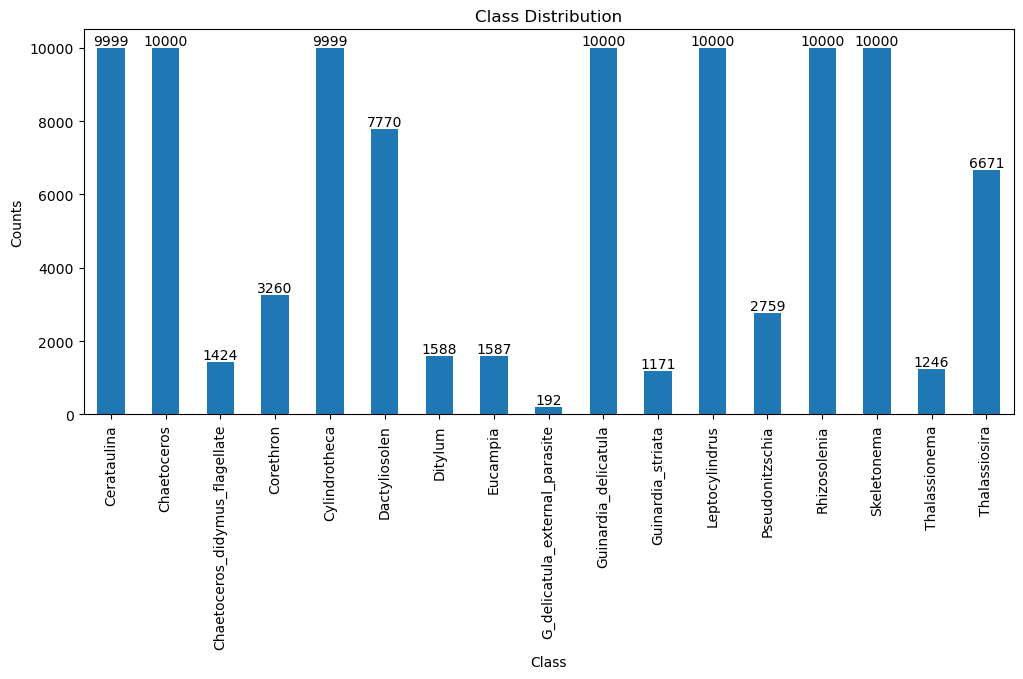

In [8]:
## Make plot
import matplotlib.pyplot as plt 
df = pd.DataFrame(data_details)

ax = df.plot(x='Class',y='Counts', kind='bar',legend = False, figsize=(12, 5))
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                
        (p.get_x() + p.get_width() / 2, p.get_height()),  
        ha="center", va="bottom"                
    )

plt.ylabel('Counts')
plt.title('Class Distribution')
plt.show()

In [9]:
## Merge categories
classes_to_merge_list = [
    [
    'Guinardia_delicatula',
    'Guinardia_striata',
    'G_delicatula_external_parasite',
   ],
   [
    'Chaetoceros',
    'Chaetoceros_didymus_flagellate',   
   ]
]
new_names_list = [
    'Guinardia',
    'Chaetoceros'
]


dataset_merged =  samples_setup.merge_classes(
    dataset = dataset_selected,
    classes_to_merge_list=classes_to_merge_list,
    new_names_list=new_names_list
    )

In [10]:
## Print details

data_details_merged = dataset_merged.get_dataset_details()
dataset_merged.print_dataset_details()



Total Dataset Size: 97666
Class Name: Cerataulina | Class Label: 0 | Count: 9999 | Prop: 0.10
Class Name: Chaetoceros | Class Label: 1 | Count: 11424 | Prop: 0.12
Class Name: Corethron | Class Label: 2 | Count: 3260 | Prop: 0.03
Class Name: Cylindrotheca | Class Label: 3 | Count: 9999 | Prop: 0.10
Class Name: Dactyliosolen | Class Label: 4 | Count: 7770 | Prop: 0.08
Class Name: Ditylum | Class Label: 5 | Count: 1588 | Prop: 0.02
Class Name: Eucampia | Class Label: 6 | Count: 1587 | Prop: 0.02
Class Name: Guinardia | Class Label: 7 | Count: 11363 | Prop: 0.12
Class Name: Leptocylindrus | Class Label: 8 | Count: 10000 | Prop: 0.10
Class Name: Pseudonitzschia | Class Label: 9 | Count: 2759 | Prop: 0.03
Class Name: Rhizosolenia | Class Label: 10 | Count: 10000 | Prop: 0.10
Class Name: Skeletonema | Class Label: 11 | Count: 10000 | Prop: 0.10
Class Name: Thalassionema | Class Label: 12 | Count: 1246 | Prop: 0.01
Class Name: Thalassiosira | Class Label: 13 | Count: 6671 | Prop: 0.07


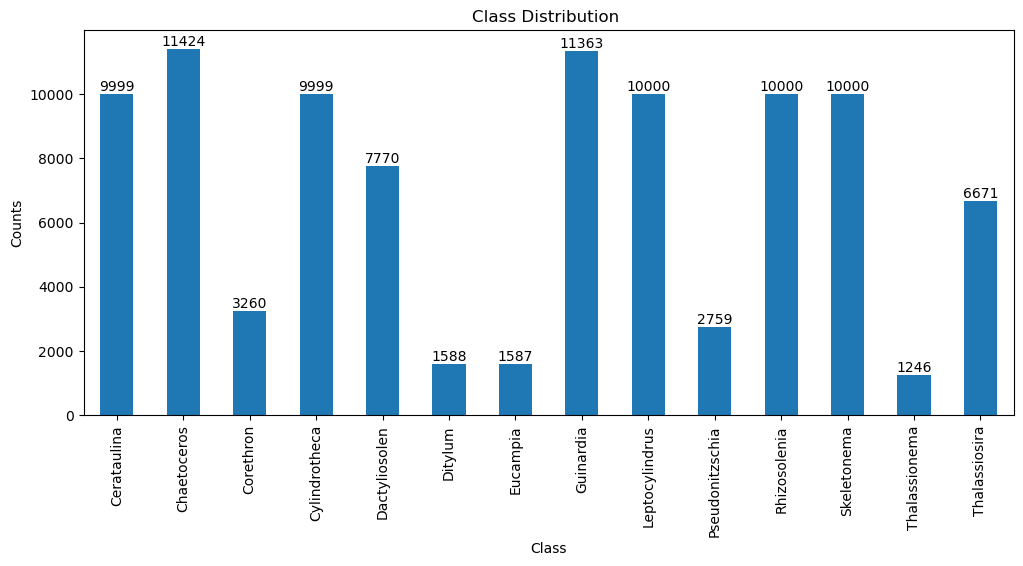

In [11]:
import matplotlib.pyplot as plt 
df = pd.DataFrame(data_details_merged)

ax = df.plot(x='Class',y='Counts', kind='bar',legend = False, figsize=(12, 5))
# Add labels on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                
        (p.get_x() + p.get_width() / 2, p.get_height()),  
        ha="center", va="bottom"                
    )

plt.ylabel('Counts')
plt.title('Class Distribution ')
plt.show()